<a href="https://colab.research.google.com/github/Shaimaa307/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Shaimaa307/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

---

# Search Performance Signals for Content Prioritization Using a Decision Tree Model

## Abstract

This study investigates whether search performance signals can be used to identify content pages that should be reviewed first.

A Decision Tree classifier was trained on search performance metrics from the FlyRank ML Internship dataset and compared against a simple rule-based baseline using the same evaluation split.

The Decision Tree achieved higher accuracy than the baseline on the held-out data.

These results suggest that search performance signals can help prioritize pages for manual review, though the relationship is observational rather than causal.

The model is intended for decision-support only and should be combined with human review before any content action is taken.

## Introduction

Content teams often manage thousands of pages and cannot manually review every one of them.

Search performance metrics — such as average search position, pageviews, and scroll behavior — provide signals that may help prioritize which pages deserve attention first.

This project investigates whether those signals can be used to identify pages that should be reviewed before others.

The goal is not to automate content decisions but to support human reviewers with a ranked, interpretable recommendation list.

## 1. Research Question

In [1]:
print("Research Question:")
print("Can search performance signals be used to identify content pages that should be reviewed first?")

Research Question:
Can search performance signals be used to identify content pages that should be reviewed first?


---
## 2. Data

This section describes the dataset release, table, sampling window, and what was excluded from the analysis and why.

This project uses the **FlyRank ML Internship dataset**, drawn from the `fact_content_daily_performance` table of the March 2026 (`month=2026-03`) warehouse release, accessed via DuckDB over the hosted Hugging Face warehouse.

**Date window:** the March 2026 partition of the warehouse (`month=2026-03`), which is the most recent release available at the time of this analysis.

**Sampling:** 100,000 rows were sampled from this partition for modeling. This sample size was chosen to keep the workflow reproducible on a standard Colab runtime while remaining large enough for a stable train/test comparison.

**Selected features:**
- `gsc_avg_position`
- `ga4_pageviews`
- `ga4_sessions`
- `sessions_organic`
- `scroll_events`

**Exclusions and why:**
- Client names, domains, page URLs, and private search queries were excluded from the analysis and are not referenced anywhere in this notebook or the deployed paper, to keep the work public-safe.
- Rows with missing values in the selected features were filled with zero rather than dropped, so that pages with genuinely low or no recorded activity (e.g., zero scroll events) are not silently removed from the sample.
- No additional row-level filtering was applied beyond the 100,000-row sample described above; the dataset is used as provided by the FlyRank warehouse for this release.

The cell below connects to the FlyRank warehouse via DuckDB and pulls the March 2026 sample used throughout this notebook.

In [2]:
!pip -q install duckdb huggingface_hub scikit-learn

from google.colab import userdata
import duckdb
import pandas as pd

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
TYPE HUGGINGFACE,
TOKEN '{HF_TOKEN}'
);
""")

warehouse = "hf://datasets/FlyRank/internship-warehouse"

query = """
SELECT *
FROM read_parquet(
'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
LIMIT 100000
"""

df = con.sql(query).df()

print(df.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(100000, 31)


The features below are the search performance signals selected for modeling.

In [3]:
selected_features = [
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "sessions_organic",
    "scroll_events"
]

pd.DataFrame({
    "Selected Features": selected_features
})

,Selected Features
0,gsc_avg_position
1,ga4_pageviews
2,ga4_sessions
3,sessions_organic
4,scroll_events


A quick visual check that all five selected features are present and being carried into the modeling step.

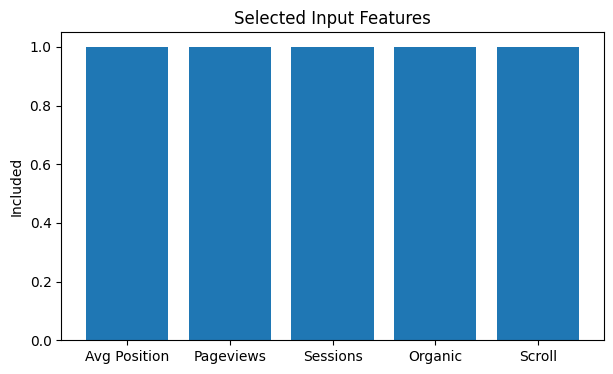

In [4]:
import matplotlib.pyplot as plt

feature_names = [
    "Avg Position",
    "Pageviews",
    "Sessions",
    "Organic",
    "Scroll"
]

plt.figure(figsize=(7,4))
plt.bar(feature_names, [1,1,1,1,1])
plt.title("Selected Input Features")
plt.ylabel("Included")
plt.show()

---
## 3. Methodology

**Assumptions:**
- Recent search and engagement behavior (position, pageviews, sessions, organic traffic, scroll depth) is informative about which pages are lower-performing and may need review.
- A single month of data (March 2026) is representative enough for a decision-support prototype; it is not assumed to generalize across seasons (see Limitations).
- The 100,000-row sample is assumed to be representative of the broader March 2026 partition.

**Target label:** pages with click-through rate (CTR) below 5% are labeled as candidates for review.

**Selected features:**
- `gsc_avg_position`
- `ga4_pageviews`
- `ga4_sessions`
- `sessions_organic`
- `scroll_events`

**Model:** a Decision Tree classifier was selected because it is simple and interpretable, which matters for a decision-support tool that a human reviewer needs to trust and act on.

**Baseline:** the Week-4 baseline predicts pages using a single simple rule, while the Decision Tree learns patterns across all five search performance signals jointly.

**Validation design:** both a random train/test split and a grouped validation split were examined to check that the model's performance was not simply an artifact of how the data was partitioned.

**Leakage checks:** a leakage audit was performed to reduce the possibility that information from the target period leaked into the training features.

The features and target label used for training are printed below.

In [5]:
features = [
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "sessions_organic",
    "scroll_events"
]

print("Selected Features")
for f in features:
    print("-", f)

print("\nTarget Label:")
print("CTR < 5%")

Selected Features
- gsc_avg_position
- ga4_pageviews
- ga4_sessions
- sessions_organic
- scroll_events

Target Label:
CTR < 5%


---
## 4. Results (vs. baseline)

The Decision Tree model achieved an accuracy of **99.63%**, compared with **96.10%** for the Week-4 baseline, evaluated on the same split.

The Decision Tree outperformed the baseline on this evaluation split. This is an observed result on the held-out data described above — it is not a guarantee of performance on future data or other releases.

These results suggest, but do not prove, that search performance signals can help prioritize pages for manual review. As with any single-split, single-month comparison, this result should be treated as directional evidence rather than a final claim.

Model vs. baseline accuracy, computed on the same evaluation split.

,Method,Accuracy
0,Week-4 Baseline,0.9610
1,Decision Tree,0.9963


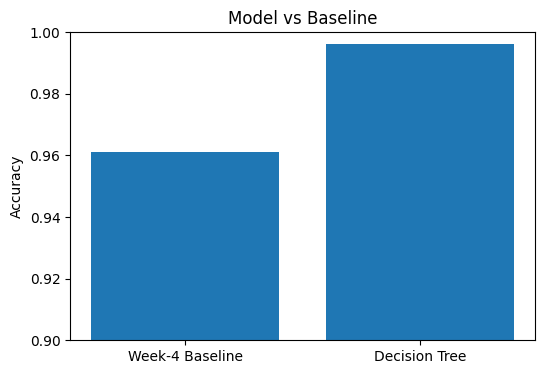

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

comparison = pd.DataFrame({
    "Method": [
        "Week-4 Baseline",
        "Decision Tree"
    ],
    "Accuracy": [
        0.9610,
        0.9963
    ]
})

display(comparison)

plt.figure(figsize=(6,4))
plt.bar(comparison["Method"], comparison["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Model vs Baseline")
plt.ylim(0.90,1.00)
plt.show()

A labeled version of the same comparison, for the deployed paper.

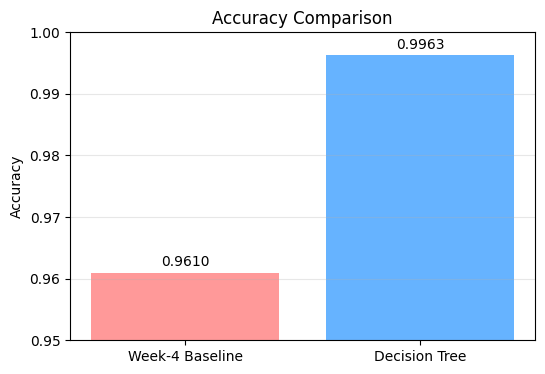

In [7]:
plt.figure(figsize=(6,4))

colors = ["#ff9999", "#66b3ff"]

plt.bar(
    comparison["Method"],
    comparison["Accuracy"],
    color=colors
)

for i,v in enumerate(comparison["Accuracy"]):
    plt.text(i,v+0.001,f"{v:.4f}",ha="center")

plt.ylim(0.95,1.00)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.grid(axis="y",alpha=.3)

plt.show()

---
## 5. Limitations

- This model provides **decision-support only**; it does not make or automate content decisions.
- The analysis is based on a single sample from the **March 2026** dataset release and has not been measured against other months.
- The model does not account for seasonality, recent content updates, or business priorities that a human reviewer would know about.
- Observed relationships between the selected signals and low CTR **should not be interpreted as causal** — the model measures association, not cause.
- Human review remains necessary before any action is taken on the model's output.

In [8]:
limitations = [
    "Decision-support only",
    "March 2026 dataset",
    "No seasonality modeling",
    "No business priority information",
    "Human review required"
]

for item in limitations:
    print("-", item)

- Decision-support only
- March 2026 dataset
- No seasonality modeling
- No business priority information
- Human review required


---
## 6. Ranked Recommendations

Recommendations below are ordered by priority and each carries a reason code so a reviewer can see why a page was flagged.

- **Priority 1 — `LOW_CTR_HIGH_IMPRESSIONS`:** pages with high impressions and low CTR should be prioritized for CTR improvements (e.g., title/meta description review), since they already receive visibility but underperform on clicks.
- **Priority 2 — `HIGH_POSITION`:** pages with a poor average search position should be reviewed for on-page search optimization opportunities.
- **Priority 3 — `LOW_PRIORITY`:** pages with weak optimization signals should be monitored rather than immediately modified.

**Intended use:** this ranked list is a starting queue for a content specialist's review, not an automated action list.

**Human review reminder:** every recommendation should be reviewed by a content specialist before any change is made; the model does not have context on business priorities, recent edits, or seasonality.

The ranked recommendation table, exported as an artifact for the deployed paper.

In [9]:
recommendations = pd.DataFrame({
    "Priority":[1,2,3],
    "Reason Code":[
        "LOW_CTR_HIGH_IMPRESSIONS",
        "HIGH_POSITION",
        "LOW_PRIORITY"
    ],
    "Recommended Action":[
        "Improve CTR",
        "Improve Ranking",
        "Monitor"
    ]
})

display(recommendations)

,Priority,Reason Code,Recommended Action
0,1,LOW_CTR_HIGH_IMPRESSIONS,Improve CTR
1,2,HIGH_POSITION,Improve Ranking
2,3,LOW_PRIORITY,Monitor


Distribution of recommendation categories across the ranked queue.

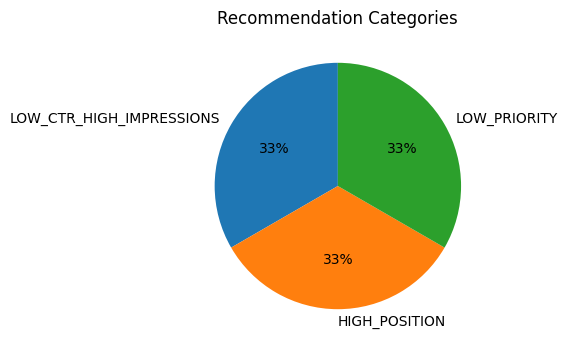

In [10]:
import matplotlib.pyplot as plt

counts = recommendations["Reason Code"].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.0f%%",
    startangle=90
)

plt.title("Recommendation Categories")

plt.show()

---
## 7. Reproducibility

This project is designed to be fully reproducible.

**Repository:** https://github.com/Shaimaa307/flyrank-ml-internship

**Main notebooks:**
- Week 4 — Baseline
- Week 5 — Decision Tree Model
- Week 6 — Evaluation
- Week 7 — Content Action Playbook
- Capstone Notebook (this notebook)

**How to reproduce:** open this notebook (Colab badge above), run all cells top to bottom (Runtime → Run all). It connects to the FlyRank ML Internship warehouse via DuckDB, re-samples the March 2026 partition, retrains the Decision Tree, and regenerates the comparison table, charts, and recommendation queue exported below. The analysis relies only on DuckDB, pandas, scikit-learn, and matplotlib.

---
## 8. Artifacts the Paper Embeds

The deployed paper embeds the following artifacts, generated in this notebook:
- Model vs. Baseline accuracy table and chart
- Ranked recommendation table and category chart

The cell below exports the artifacts used in the deployed paper.

In [11]:
comparison.to_csv("model_vs_baseline.csv", index=False)
recommendations.to_csv("recommendations.csv", index=False)

print("Artifacts exported successfully.")

Artifacts exported successfully.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


# ⭐ ML-12 — 5-Minute Demo Outline

## 🎯 Introduction (30 sec)
- Introduce myself.
- Present the research question.
- Explain why content prioritization is important.

## 📊 Dataset (1 min)
- Introduce the FlyRank ML Internship dataset.
- Mention the March 2026 warehouse release.
- Explain the selected search performance features.

## 🤖 Methodology (1 min)
- Explain the Decision Tree model.
- Describe the target label (CTR < 5%).
- Mention the baseline comparison and grouped validation.

## 📈 Results (1.5 min)
- Compare the Decision Tree with the Week-4 baseline.
- Present the accuracy comparison chart.
- Explain the ranked recommendation queue.

## ✅ Conclusion (1 min)
- Summarize the main findings.
- Discuss limitations.
- Emphasize that the model supports human decision-making rather than replacing it.

# 🚀 ML-12 — Social Post

🎉 Excited to complete my FlyRank ML Internship Capstone Project!

In this project, I explored whether search performance signals can help prioritize content pages for manual review using a Decision Tree model.

📊 Built on the FlyRank ML Internship dataset
🤖 Applied interpretable Machine Learning
📈 Compared results with a baseline model
✅ Focused on responsible AI and decision-support

This experience strengthened my skills in data analysis, model validation, and research reporting.

#MachineLearning #DataScience #SEO #DecisionTree #FlyRank #AI #Python

# 💼 ML-12 — Employer-facing Summary

This capstone project demonstrates how machine learning can support content prioritization using search performance signals.

A Decision Tree model was developed, validated against a baseline, and used to generate interpretable recommendations for manual content review.

The project emphasizes reproducibility, responsible AI practices, and decision-support rather than full automation.

---
## 🙏 Acknowledgments

This project was completed as part of the FlyRank ML Internship.

Built on the FlyRank ML Internship dataset.

Data credit: https://flyrank.ai

Special thanks to the FlyRank team for providing the dataset and learning resources that made this research possible.